In [27]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [9]:
IMAGE_PATH = "/Users/joaquincibeira/INA/346.png"

In [38]:
image = cv2.imread(IMAGE_PATH, cv2.COLOR_BGR2GRAY)

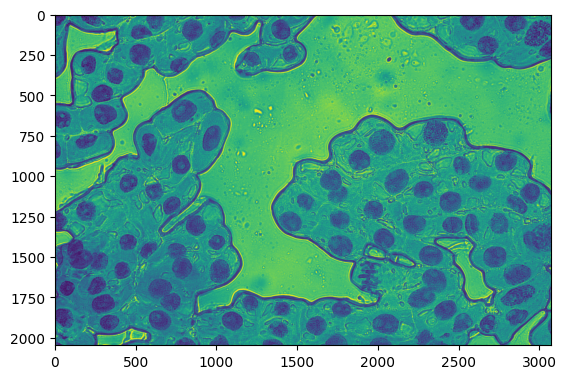

In [39]:
plt.imshow(image)
plt.show()

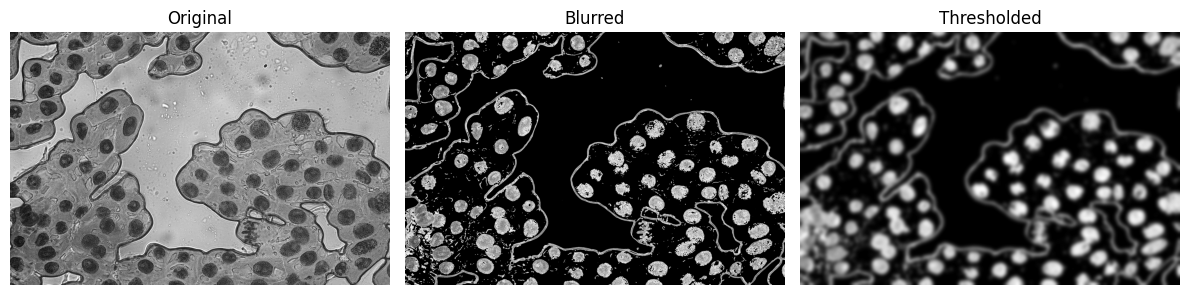

In [44]:
blurred = cv2.GaussianBlur(image, (11, 11), 0)

_, thresh = cv2.threshold(blurred, 100, 255, cv2.THRESH_TOZERO_INV)

blurred_2 = cv2.GaussianBlur(thresh, (101, 101), 0)


# Plot the original, blurred, and thresholded images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Original')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Blurred')
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Thresholded')
plt.imshow(blurred_2, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

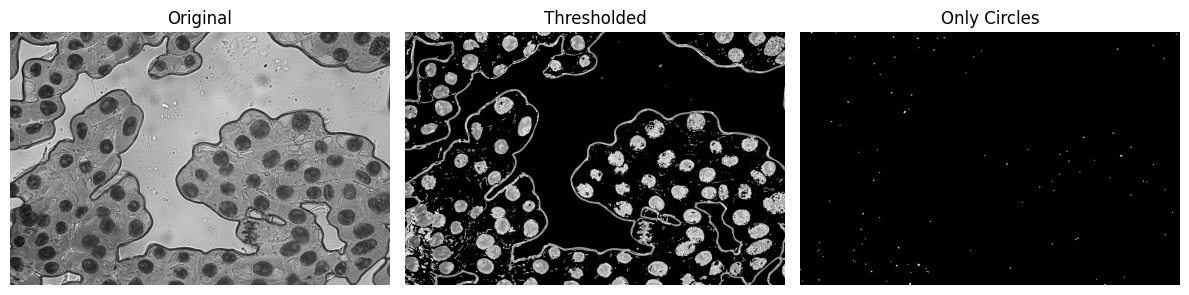

In [47]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Find contours
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create output mask for detected circles
circle_mask = np.zeros_like(image)

# Loop through contours and keep only circles
for cnt in contours:
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    if perimeter == 0 or area == 0:
        continue
    circularity = 4 * np.pi * (area / (perimeter * perimeter))

    if 0.7 < circularity < 1.2 and 30 < area < 300:  # These ranges are important
        cv2.drawContours(circle_mask, [cnt], -1, 255, -1)

# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Original')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Thresholded')
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Only Circles')
plt.imshow(circle_mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()